In [1]:
import os
import random
import shutil
from pathlib import Path

# ==================== CẤU HÌNH ====================
SOURCE_DIR = Path(
    "/kaggle/input/datasets/gsk7625/bellevue-116th-ne12th/content/dataset"
)

IMAGES_DIR = SOURCE_DIR / "images"
LABELS_DIR = SOURCE_DIR / "labels"

FINAL_DATASET_DIR = Path("/kaggle/working/dataset_final")
# ==================================================

# Xóa dataset cũ nếu tồn tại
if FINAL_DATASET_DIR.exists():
    shutil.rmtree(FINAL_DATASET_DIR)

# 1. Tìm các cặp ảnh - nhãn hợp lệ
print("--> Đang quét dữ liệu...")

all_valid_pairs = []

for img_path in IMAGES_DIR.glob("*"):

    if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
        continue

    label_path = LABELS_DIR / f"{img_path.stem}.txt"

    if label_path.exists():
        all_valid_pairs.append({
            "img_path": img_path,
            "lbl_path": label_path,
            "img_name": img_path.name,
            "lbl_name": label_path.name
        })

total_pairs = len(all_valid_pairs)

print(f"--> Tìm thấy {total_pairs} cặp ảnh/nhãn hợp lệ")

if total_pairs == 0:
    raise ValueError("Không tìm thấy dữ liệu!")

# 2. Tạo cấu trúc YOLO
for split in ["train", "val", "test"]:
    (FINAL_DATASET_DIR / split / "images").mkdir(parents=True, exist_ok=True)
    (FINAL_DATASET_DIR / split / "labels").mkdir(parents=True, exist_ok=True)

# 3. Shuffle
random.seed(42)
random.shuffle(all_valid_pairs)

# 4. Chia 80/10/10
num_val = int(total_pairs * 0.1)
num_test = int(total_pairs * 0.1)

val_pairs = all_valid_pairs[:num_val]
test_pairs = all_valid_pairs[num_val:num_val + num_test]
train_pairs = all_valid_pairs[num_val + num_test:]

print("\nKế hoạch phân chia:")
print(f"TRAIN: {len(train_pairs)}")
print(f"VAL  : {len(val_pairs)}")
print(f"TEST : {len(test_pairs)}")

# 5. Copy dữ liệu
def copy_to_split(pairs, split_name):

    total = len(pairs)

    for idx, pair in enumerate(pairs, start=1):

        shutil.copy2(
            pair["img_path"],
            FINAL_DATASET_DIR / split_name / "images" / pair["img_name"]
        )

        shutil.copy2(
            pair["lbl_path"],
            FINAL_DATASET_DIR / split_name / "labels" / pair["lbl_name"]
        )

        if idx % max(1, total // 10) == 0 or idx == total:
            percent = int(idx / total * 100)
            print(
                f"[{split_name.upper()}] "
                f"{percent}% ({idx}/{total})"
            )

print("\nCopy VAL...")
copy_to_split(val_pairs, "val")

print("\nCopy TEST...")
copy_to_split(test_pairs, "test")

print("\nCopy TRAIN...")
copy_to_split(train_pairs, "train")

# 6. Kiểm tra kết quả
print("\n===== KẾT QUẢ =====")

for split in ["train", "val", "test"]:

    num_imgs = len(
        list((FINAL_DATASET_DIR / split / "images").glob("*"))
    )

    num_lbls = len(
        list((FINAL_DATASET_DIR / split / "labels").glob("*"))
    )

    print(
        f"{split.upper()}: "
        f"{num_imgs} images | {num_lbls} labels"
    )

print(f"\nDataset đã lưu tại:")
print(FINAL_DATASET_DIR)

--> Đang quét dữ liệu...
--> Tìm thấy 12473 cặp ảnh/nhãn hợp lệ

Kế hoạch phân chia:
TRAIN: 9979
VAL  : 1247
TEST : 1247

Copy VAL...
[VAL] 9% (124/1247)
[VAL] 19% (248/1247)
[VAL] 29% (372/1247)
[VAL] 39% (496/1247)
[VAL] 49% (620/1247)
[VAL] 59% (744/1247)
[VAL] 69% (868/1247)
[VAL] 79% (992/1247)
[VAL] 89% (1116/1247)
[VAL] 99% (1240/1247)
[VAL] 100% (1247/1247)

Copy TEST...
[TEST] 9% (124/1247)
[TEST] 19% (248/1247)
[TEST] 29% (372/1247)
[TEST] 39% (496/1247)
[TEST] 49% (620/1247)
[TEST] 59% (744/1247)
[TEST] 69% (868/1247)
[TEST] 79% (992/1247)
[TEST] 89% (1116/1247)
[TEST] 99% (1240/1247)
[TEST] 100% (1247/1247)

Copy TRAIN...
[TRAIN] 9% (997/9979)
[TRAIN] 19% (1994/9979)
[TRAIN] 29% (2991/9979)
[TRAIN] 39% (3988/9979)
[TRAIN] 49% (4985/9979)
[TRAIN] 59% (5982/9979)
[TRAIN] 69% (6979/9979)
[TRAIN] 79% (7976/9979)
[TRAIN] 89% (8973/9979)
[TRAIN] 99% (9970/9979)
[TRAIN] 100% (9979/9979)

===== KẾT QUẢ =====
TRAIN: 9979 images | 9979 labels
VAL: 1247 images | 1247 labels
TEST: 1247

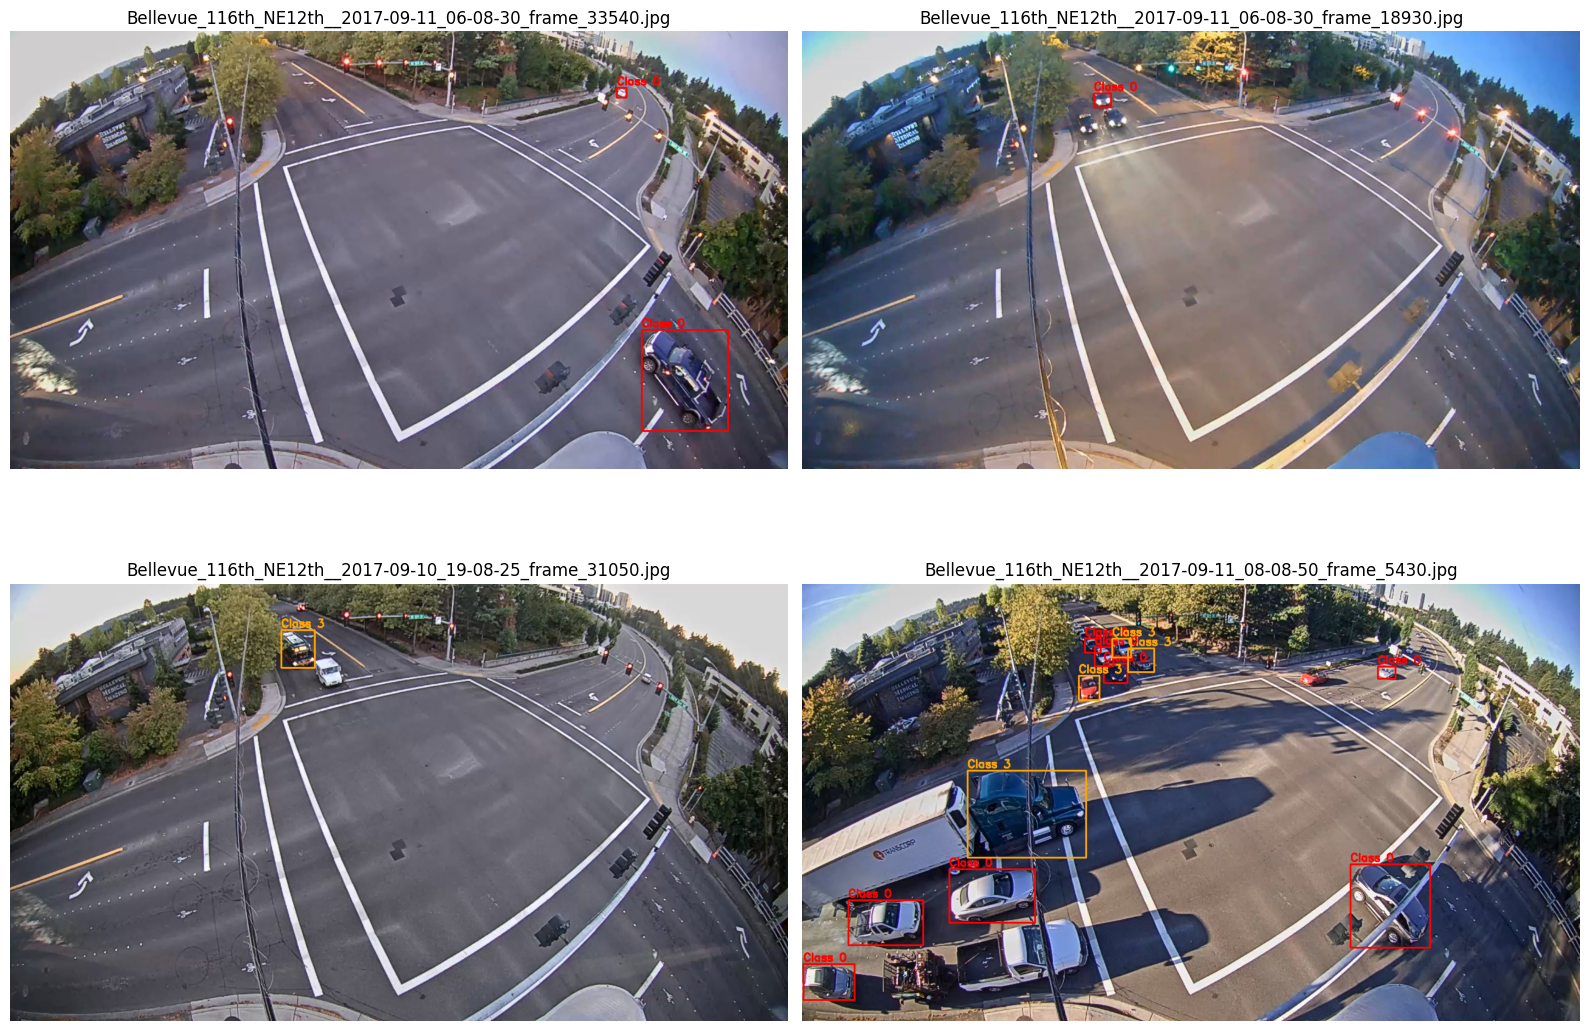

In [2]:
import cv2
import random
import matplotlib.pyplot as plt
from pathlib import Path

# ==================== CẤU HÌNH ====================
IMAGE_DIR = Path("/kaggle/working/dataset_final/train/images")
LABEL_DIR = Path("/kaggle/working/dataset_final/train/labels")

NUM_SAMPLES = 4
# ==================================================

# Lấy danh sách ảnh
image_files = []

for ext in ["*.jpg", "*.jpeg", "*.png"]:
    image_files.extend(list(IMAGE_DIR.glob(ext)))

if len(image_files) == 0:
    raise ValueError(f"Không tìm thấy ảnh trong {IMAGE_DIR}")

# Chọn ngẫu nhiên
sample_images = random.sample(
    image_files,
    min(NUM_SAMPLES, len(image_files))
)

# Tự sinh màu theo class
COLORS = [
    (255, 0, 0),
    (0, 255, 0),
    (0, 0, 255),
    (255, 165, 0),
    (255, 0, 255),
    (0, 255, 255),
]

rows = (len(sample_images) + 1) // 2
fig, axes = plt.subplots(rows, 2, figsize=(16, rows * 6))

if rows == 1:
    axes = axes.flatten()
else:
    axes = axes.ravel()

for idx, img_path in enumerate(sample_images):

    image = cv2.imread(str(img_path))

    if image is None:
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w = image.shape[:2]

    label_file = LABEL_DIR / f"{img_path.stem}.txt"

    if label_file.exists():

        with open(label_file, "r") as f:
            labels = f.readlines()

        for line in labels:

            data = line.strip().split()

            if len(data) != 5:
                continue

            cls_id = int(float(data[0]))

            xc, yc, bw, bh = map(float, data[1:])

            x1 = int((xc - bw / 2) * w)
            y1 = int((yc - bh / 2) * h)

            x2 = int((xc + bw / 2) * w)
            y2 = int((yc + bh / 2) * h)

            color = COLORS[cls_id % len(COLORS)]

            cv2.rectangle(
                image,
                (x1, y1),
                (x2, y2),
                color,
                2
            )

            cv2.putText(
                image,
                f"Class {cls_id}",
                (x1, max(20, y1 - 5)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                color,
                2
            )

    axes[idx].imshow(image)
    axes[idx].set_title(img_path.name)
    axes[idx].axis("off")

# Ẩn ô trống nếu số ảnh < số subplot
for i in range(len(sample_images), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

📊 SƠ LƯỢC TẬP DỮ LIỆU HUẤN LUYỆN:
   > Tổng số file ảnh tìm thấy: 9979
   > Tổng số file nhãn (.txt): 9979
   > Tổng số ô vuông (Bounding Boxes): 54717
   > Trung bình có 5.5 phương tiện trên mỗi khung hình.



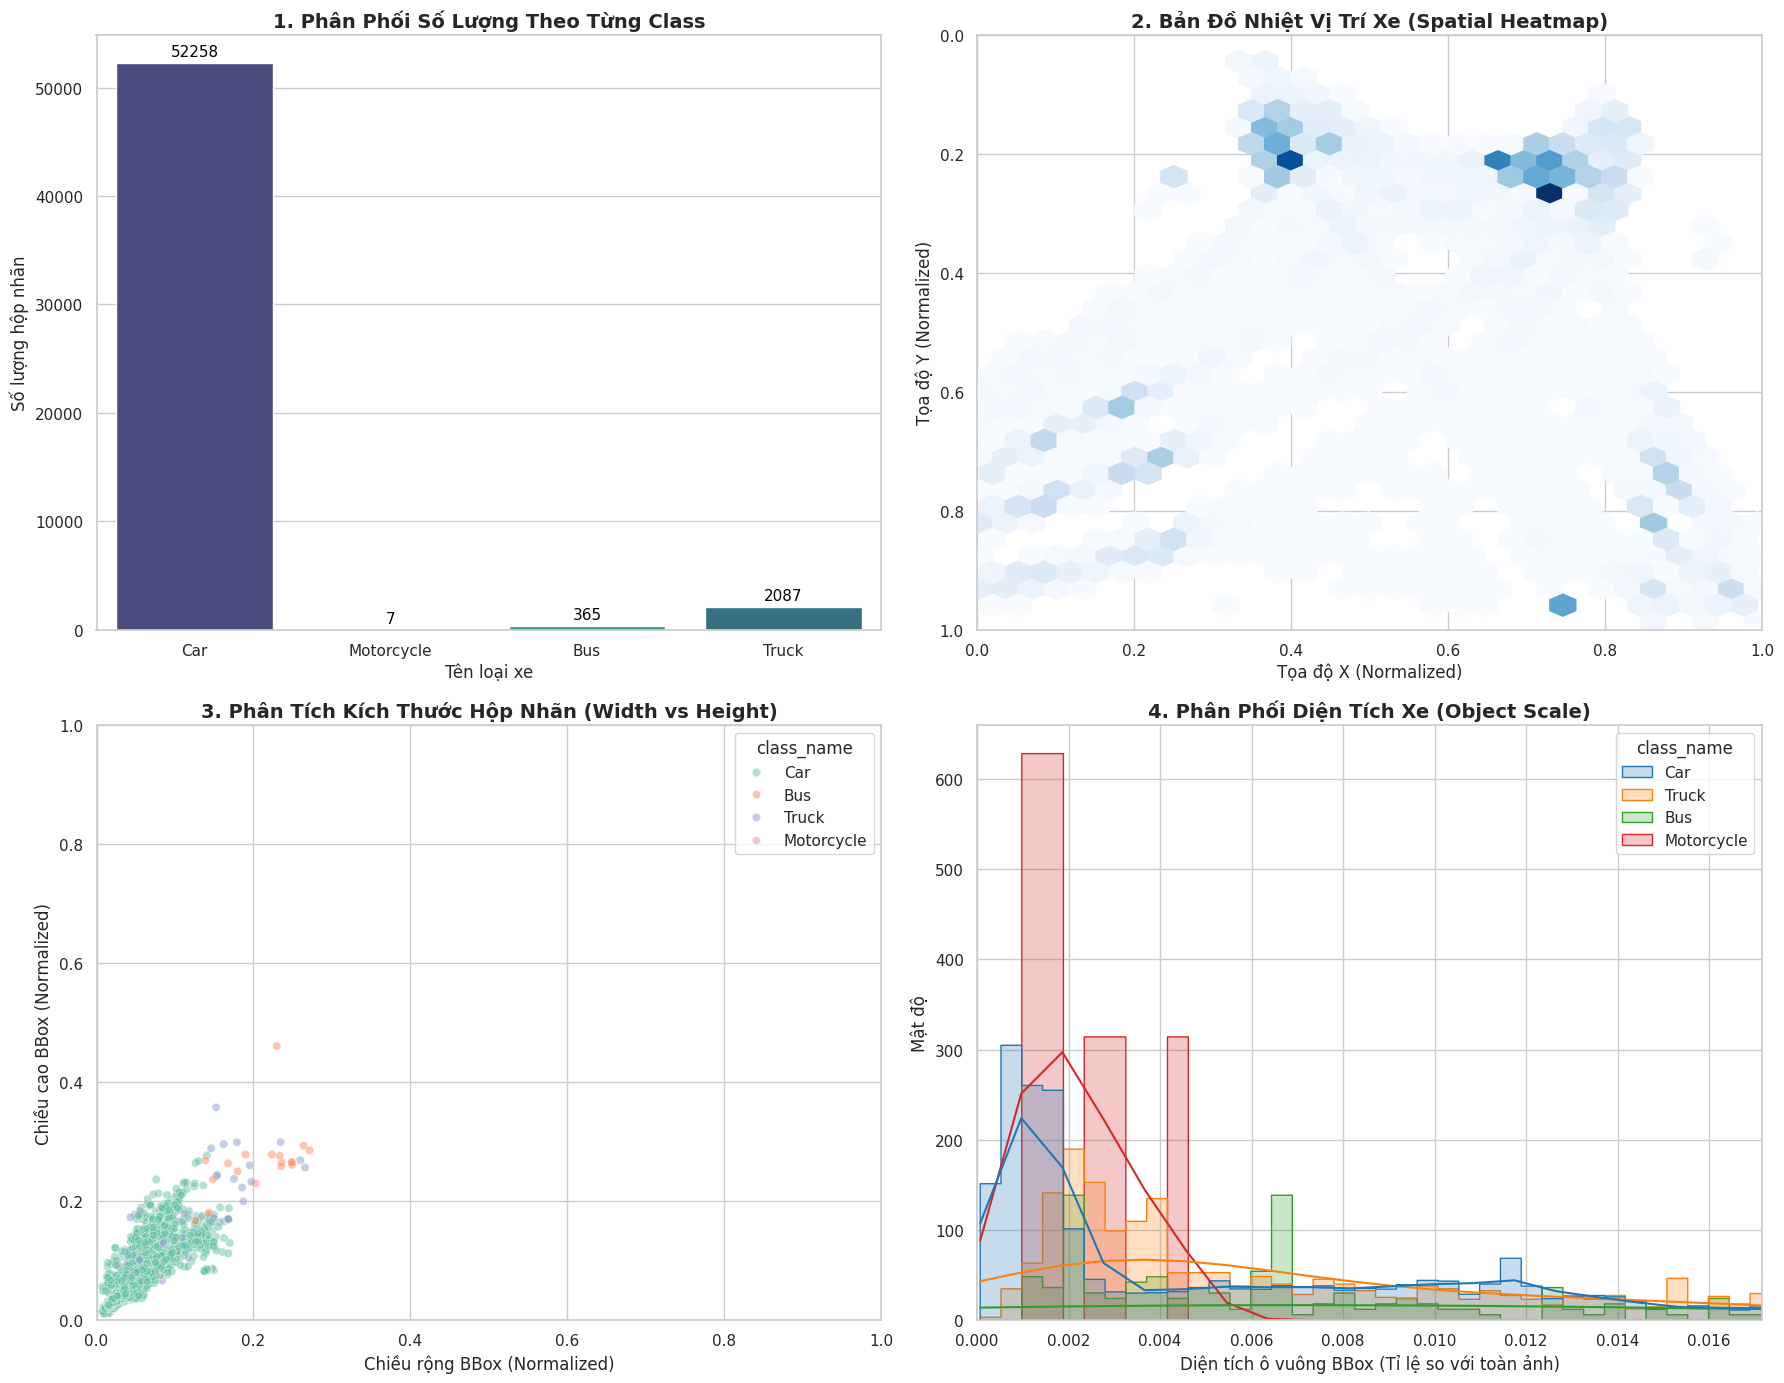

In [3]:
import os
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ==================== CẤU HÌNH ĐƯỜNG DẪN KAGGLE ====================
# Trỏ trực tiếp vào tập dữ liệu chuẩn vừa chia ở bước trước trên Kaggle
IMAGE_DIR = Path('/kaggle/working/dataset_final/train/images')
LABEL_DIR = Path('/kaggle/working/dataset_final/train/labels')

CLASS_NAMES = {0: 'Car', 1: 'Motorcycle', 2: 'Bus', 3: 'Truck'}
# ===================================================================

# Đọc toàn bộ file nhãn và trích xuất thông tin hình học
bbox_data = []

# Đếm số lượng ảnh thực tế hỗ trợ đa định dạng (.jpg, .jpeg, .png)
valid_extensions = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']
total_images = 0
for ext in valid_extensions:
    total_images += len(glob.glob(str(IMAGE_DIR / ext)))

# Lấy danh sách file nhãn
label_files = glob.glob(str(LABEL_DIR / "*.txt"))
total_labels = len(label_files)

for file_path in label_files:
    with open(file_path, 'r') as f:
        lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if len(parts) == 5:
                cls_id = int(parts[0])
                x_c, y_c, w, h = map(float, parts[1:])
                bbox_data.append({
                    'class_id': cls_id,
                    'class_name': CLASS_NAMES.get(cls_id, f"Unknown_{cls_id}"),
                    'x_center': x_c,
                    'y_center': y_c,
                    'width': w,
                    'height': h,
                    'area': w * h,
                    'aspect_ratio': w / (h + 1e-6)
                })

if len(bbox_data) == 0:
    print("[CẢNH BÁO] Chưa trích xuất được hộp nhãn nào. Hãy chắc chắn tập train của bạn có chứa file .txt hợp lệ.")
    exit()

df = pd.DataFrame(bbox_data)

print(f"📊 SƠ LƯỢC TẬP DỮ LIỆU HUẤN LUYỆN:")
print(f"   > Tổng số file ảnh tìm thấy: {total_images}")
print(f"   > Tổng số file nhãn (.txt): {total_labels}")
print(f"   > Tổng số ô vuông (Bounding Boxes): {len(df)}")
print(f"   > Trung bình có {len(df)/max(1, total_labels):.1f} phương tiện trên mỗi khung hình.\n")

# Khởi tạo khung vẽ 2x2 chỉn chu với Seaborn
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# -------------------------------------------------------------
# ĐỒ THỊ 1: Phân phối số lượng theo từng Class
# -------------------------------------------------------------
# Đảm bảo bảng màu 'viridis' không bị lỗi palette trong các phiên bản Seaborn mới
sns.countplot(
    data=df, 
    x='class_name', 
    order=[CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys()) if CLASS_NAMES[i] in df['class_name'].unique()],
    palette="viridis", 
    hue='class_name',  # Thêm hue để tránh cảnh báo phân tách thuộc tính từ Seaborn mới
    legend=False,
    ax=axes[0, 0]
)
axes[0, 0].set_title("1. Phân Phối Số Lượng Theo Từng Class", fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel("Tên loại xe")
axes[0, 0].set_ylabel("Số lượng hộp nhãn")

# Ghi chữ hiển thị số lượng cụ thể trên đầu mỗi cột thanh
for p in axes[0, 0].patches:
    height = p.get_height()
    if not np.isnan(height):
        axes[0, 0].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                            ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')

# -------------------------------------------------------------
# ĐỒ THỊ 2: Heatmap mật độ vị trí tâm vật thể (Spatial Distribution)
# -------------------------------------------------------------
axes[0, 1].hexbin(df['x_center'], df['y_center'], gridsize=30, cmap='Blues', mincnt=1)
axes[0, 1].set_title("2. Bản Đồ Nhiệt Vị Trí Xe (Spatial Heatmap)", fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel("Tọa độ X (Normalized)")
axes[0, 1].set_ylabel("Tọa độ Y (Normalized)")
axes[0, 1].set_xlim(0, 1)
axes[0, 1].set_ylim(1, 0) # Đảo ngược trục Y khớp với hệ trục ảnh gốc (0,0 ở góc trên bên trái)

# -------------------------------------------------------------
# ĐỒ THỊ 3: Biểu đồ phân tán Kích thước Rộng vs Cao (Aspect Ratio Analysis)
# -------------------------------------------------------------
# Lấy mẫu ngẫu nhiên tối đa 5000 điểm để biểu đồ mượt mà, không bị lag trình duyệt
df_sample = df.sample(n=min(5000, len(df)), random_state=42)
sns.scatterplot(data=df_sample, x='width', y='height', hue='class_name', alpha=0.5, palette="Set2", ax=axes[1, 0])
axes[1, 0].set_title("3. Phân Tích Kích Thước Hộp Nhãn (Width vs Height)", fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel("Chiều rộng BBox (Normalized)")
axes[1, 0].set_ylabel("Chiều cao BBox (Normalized)")
axes[1, 0].set_xlim(0, 1)
axes[1, 0].set_ylim(0, 1)

# -------------------------------------------------------------
# ĐỒ THỊ 4: Phân phối diện tích vật thể (Object Scale Distribution)
# -------------------------------------------------------------
sns.histplot(data=df, x='area', hue='class_name', element='step', stat='density', common_norm=False, kde=True, palette="tab10", ax=axes[1, 1])
axes[1, 1].set_title("4. Phân Phối Diện Tích Xe (Object Scale)", fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel("Diện tích ô vuông BBox (Tỉ lệ so với toàn ảnh)")
axes[1, 1].set_ylabel("Mật độ")
axes[1, 1].set_xlim(0, float(df['area'].quantile(0.95))) # Giới hạn ở phân vị 95% để quan sát kỹ vật thể nhỏ tốt hơn

plt.tight_layout()
plt.show()

In [4]:
import os
import glob
import random
import shutil
from pathlib import Path

# Thiết lập seed để nếu chạy lại nhiều lần sẽ cho ra cùng một tập dữ liệu bị xóa
random.seed(42)

# ==================== CẤU HÌNH BIẾN CÂN BẰNG KAGGLE ====================
DATASET_DIR = Path('/kaggle/working/dataset_final')

# Tỷ lệ GIỮ LẠI các ảnh CHỈ CHỨA TOÀN CAR (0.15 tức là giữ 15%, loại bỏ 85%)
# Gốc có ~52k ảnh Car, giữ 15% sẽ còn khoảng ~7.8k ảnh chỉ chứa Car.
# Khi cộng thêm các xe Car nằm chung trong ảnh Bus/Truck, tổng số lượng Car sẽ rất cân bằng.
CAR_ONLY_KEEP_RATIO = 0.15

# Quy hoạch Class mới: Bỏ Motorcycle (1)
# Cũ: 0: Car, 1: Motorcycle, 2: Bus, 3: Truck
# Mới: 0: Car, 1: Bus, 2: Truck
CLASS_REMAP = {
    0: 0,  # Car giữ nguyên 0
    2: 1,  # Bus chuyển thành 1
    3: 2   # Truck chuyển thành 2
}
# =======================================================================

print("--- BẮT ĐẦU TIẾN TRÌNH LÀM SẠCH (REMAP) VÀ GIẢM MẪU (UNDERSAMPLING) ---")

valid_extensions = ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']

# -------------------------------------------------------------
# BƯỚC 1: XỬ LÝ TẬP TRAIN (CÓ ÁP DỤNG UNDERSAMPLING)
# -------------------------------------------------------------
print("\n[Bước 1] Đang xử lý tập TRAIN...")

train_label_dir = DATASET_DIR / 'train' / 'labels'
train_image_dir = DATASET_DIR / 'train' / 'images'

train_labels = glob.glob(str(train_label_dir / "*.txt"))

deleted_count = 0
kept_count = 0

for file_path in train_labels:
    p_file = Path(file_path)
    base_name = p_file.stem
    
    # Tìm file ảnh tương ứng
    src_img_path = None
    for ext in valid_extensions:
        temp_path = train_image_dir / f"{base_name}{ext}"
        if temp_path.exists():
            src_img_path = temp_path
            break
            
    modified_lines = []
    has_minority = False  # Biến kiểm tra xem ảnh có chứa Bus hoặc Truck không
    
    with open(file_path, 'r') as f:
        lines = f.readlines()
        
    for line in lines:
        parts = line.strip().split()
        if len(parts) == 5:
            old_cls = int(parts[0])
            # Nếu là Car, Bus, Truck thì xử lý, gặp Motorcycle (1) thì bỏ qua hoàn toàn
            if old_cls in CLASS_REMAP:
                new_cls = CLASS_REMAP[old_cls]
                if new_cls in [1, 2]:  # Nếu là Bus hoặc Truck sau khi remap
                    has_minority = True
                modified_lines.append(f"{new_cls} {parts[1]} {parts[2]} {parts[3]} {parts[4]}\n")

    # Quyết định Giữ hoặc Xóa ảnh dựa trên thành phần class
    if has_minority:
        # BẮT BUỘC GIỮ nếu có Bus hoặc Truck
        with open(file_path, 'w') as f:
            f.writelines(modified_lines)
        kept_count += 1
    else:
        # Ảnh CHỈ chứa Car (hoặc trống rỗng sau khi xóa Motorcycle) -> Tiến hành tung xúc xắc giảm mẫu
        if random.random() < CAR_ONLY_KEEP_RATIO:
            # Được chọn giữ lại
            with open(file_path, 'w') as f:
                f.writelines(modified_lines)
            kept_count += 1
        else:
            # Bị loại bỏ: Xóa cả file nhãn và file ảnh tương ứng
            if p_file.exists():
                os.remove(file_path)
            if src_img_path and src_img_path.exists():
                os.remove(src_img_path)
            deleted_count += 1

print(f"✅ Tập TRAIN hoàn tất: Giữ lại {kept_count} ảnh | Đã xóa bỏ {deleted_count} ảnh chỉ chứa toàn Car.")

# -------------------------------------------------------------
# BƯỚC 2: XỬ LÝ TẬP VAL VÀ TEST (CHỈ REMAP ID, KHÔNG XÓA ẢNH)
# -------------------------------------------------------------
print("\n[Bước 2] Đang làm sạch nhãn cho tập VAL và TEST...")

for split in ['val', 'test']:
    label_files = glob.glob(str(DATASET_DIR / split / "labels" / "*.txt"))
    for file_path in label_files:
        modified_lines = []
        with open(file_path, 'r') as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            if len(parts) == 5:
                old_cls = int(parts[0])
                if old_cls in CLASS_REMAP:
                    new_cls = CLASS_REMAP[old_cls]
                    modified_lines.append(f"{new_cls} {parts[1]} {parts[2]} {parts[3]} {parts[4]}\n")

        with open(file_path, 'w') as f:
            f.writelines(modified_lines)

print("✅ Tập VAL và TEST đã được dọn dẹp nhãn thành công.")

# -------------------------------------------------------------
# BƯỚC 3: CẬP NHẬT FILE DATA.YAML MỚI
# -------------------------------------------------------------
print("\n[Bước 3] Đang cấu hình lại file data.yaml...")

yaml_content = f"""
path: {str(DATASET_DIR)}
train: train/images
val: val/images
test: test/images

names:
  0: car
  1: bus
  2: truck
"""

with open(str(DATASET_DIR / "data.yaml"), "w") as f:
    f.write(yaml_content.strip())

print("✅ Đã cập nhật data.yaml cấu trúc 3 Class mới thành công.")
print("\n=== DATASET ĐÃ ĐƯỢC ĐƯA VỀ TRẠNG THÁI CÂN BẰNG LÝ TƯỞNG! ===")

--- BẮT ĐẦU TIẾN TRÌNH LÀM SẠCH (REMAP) VÀ GIẢM MẪU (UNDERSAMPLING) ---

[Bước 1] Đang xử lý tập TRAIN...
✅ Tập TRAIN hoàn tất: Giữ lại 3273 ảnh | Đã xóa bỏ 6706 ảnh chỉ chứa toàn Car.

[Bước 2] Đang làm sạch nhãn cho tập VAL và TEST...
✅ Tập VAL và TEST đã được dọn dẹp nhãn thành công.

[Bước 3] Đang cấu hình lại file data.yaml...
✅ Đã cập nhật data.yaml cấu trúc 3 Class mới thành công.

=== DATASET ĐÃ ĐƯỢC ĐƯA VỀ TRẠNG THÁI CÂN BẰNG LÝ TƯỞNG! ===


📊 THỐNG KÊ TẬP TRAIN SAU KHI GIẢM MẪU (UNDERSAMPLING):
class_name
Car      19227
Truck     2087
Bus        365
Name: count, dtype: int64


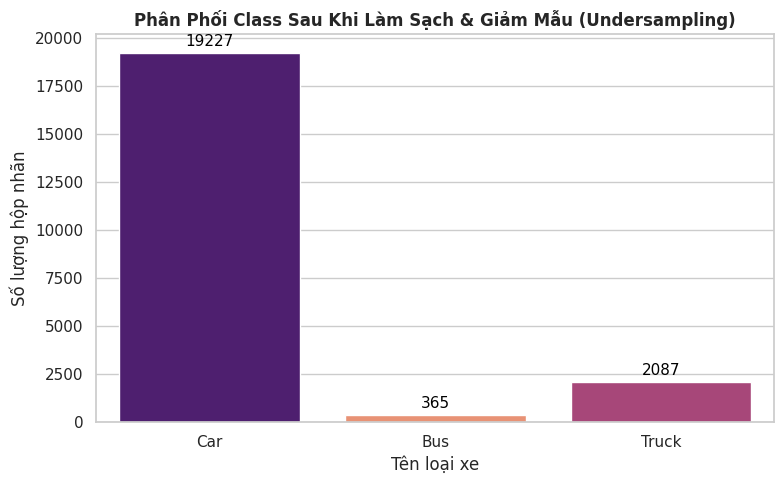

In [5]:
import os
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==================== CẤU HÌNH ĐƯỜNG DẪN KAGGLE ====================
# Trỏ vào tập train trong thư mục làm việc của Kaggle
TRAIN_LABEL_DIR = '/kaggle/working/dataset_final/train/labels'
# ===================================================================

# Đếm lại số lượng nhãn sau khi xử lý giảm mẫu
new_bbox_data = []
label_files = glob.glob(f"{TRAIN_LABEL_DIR}/*.txt")

for file_path in label_files:
    with open(file_path, 'r') as f:
        for line in f.readlines():
            parts = line.split()
            if parts:  # Kiểm tra dòng không bị rỗng
                new_bbox_data.append(int(parts[0]))

if len(new_bbox_data) == 0:
    print("[LỖI] Không tìm thấy nhãn nào trong thư mục. Hãy chắc chắn rằng bước xử lý trước đó đã thành công.")
    exit()

df_new = pd.DataFrame(new_bbox_data, columns=['class_id'])
# Cập nhật lại Map sang 3 Class (Đã loại bỏ Motorcycle)
df_new['class_name'] = df_new['class_id'].map({0: 'Car', 1: 'Bus', 2: 'Truck'})

print("📊 THỐNG KÊ TẬP TRAIN SAU KHI GIẢM MẪU (UNDERSAMPLING):")
print(df_new['class_name'].value_counts())

# Vẽ biểu đồ cột mới chỉn chu
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# Thêm cấu hình hue, legend và order để tối ưu theo thư viện Seaborn mới trên Kaggle
sns.countplot(
    data=df_new, 
    x='class_name', 
    palette='magma', 
    hue='class_name', 
    legend=False,
    order=['Car', 'Bus', 'Truck']  # Cố định thứ tự 3 class
)

# Hiển thị số lượng cụ thể ngay trên đầu mỗi cột
ax = plt.gca()
for p in ax.patches:
    height = p.get_height()
    # Kiểm tra > 0 để tránh in số 0 nếu lỡ có cột rỗng
    if height > 0:
        ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')

plt.title("Phân Phối Class Sau Khi Làm Sạch & Giảm Mẫu (Undersampling)", fontsize=12, fontweight='bold')
plt.xlabel("Tên loại xe")
plt.ylabel("Số lượng hộp nhãn")
plt.tight_layout()
plt.show()

In [6]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 98.6 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 w

In [7]:
import os
from ultralytics import YOLO

# 1. Khởi tạo mô hình bản Medium (YOLOv11m) 
model = YOLO('yolo11m.pt')

print("--- BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH TRAFFIC CUSTOM TRÊN KAGGLE ---")

# 2. Tiến hành Train với các tham số chuẩn xác nhất
results = model.train(
    data='/kaggle/working/dataset_final/data.yaml',  
    epochs=100,         
    imgsz=640,          
    batch=16,           
    device=0,           
    workers=2,          
    cache=True,         
    
    # TỐI ƯU HUẤN LUYỆN
    patience=20,        # Dừng sớm nếu sau 20 epoch không cải thiện mAP
    cos_lr=True,        # Giảm Learning Rate theo hình sin, giúp hội tụ tốt hơn
    
    # TĂNG CƯỜNG DỮ LIỆU (AUGMENTATION - Đã được kiểm chứng không báo lỗi)
    mosaic=1.0,         # Ghép 4 ảnh thành 1
    mixup=0.15,         # Trộn ảnh để học xe bị che khuất
    scale=0.5,          # Thu phóng giúp học xe li ti
    degrees=15.0,       # Xoay ảnh mô phỏng camera rung lắc/nghiêng
    translate=0.2,      # Dịch chuyển vị trí xe ra khỏi trung tâm
    perspective=0.0005, # Bóp méo phối cảnh (cực kỳ tốt cho góc camera từ trên cao)

    # ĐƯỜNG DẪN ĐẦU RA
    project='/kaggle/working/yolo_traffic_project',  
    name='traffic_yolo_sumo'
)

print("\n=== QUÁ TRÌNH HUẤN LUYỆN HOÀN TẤT! ===")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
--- BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH TRAFFIC CUSTOM TRÊN KAGGLE ---
Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/dataset_final/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fracti